In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train[:10000]
y_train = y_train[:10000]

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = tf.image.resize(X_train, (96,96))
X_test = tf.image.resize(X_test, (96,96))

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [3]:
def build_model(base_model):
    
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))

mobilenet_model = build_model(mobilenet_base)

history_mobilenet = mobilenet_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=16
)

mobilenet_acc = mobilenet_model.evaluate(X_test, y_test)[1]

print("MobileNetV2 Accuracy:", mobilenet_acc)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.6414 - loss: 1.0358 - val_accuracy: 0.7286 - val_loss: 0.7729
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.7468 - loss: 0.7390 - val_accuracy: 0.7684 - val_loss: 0.6636
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7758 - loss: 0.6511 - val_accuracy: 0.7563 - val_loss: 0.6953
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.7563 - loss: 0.6953
MobileNetV2 Accuracy: 0.7562999725341797


In [5]:
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(96,96,3))

efficientnet_model = build_model(efficientnet_base)

history_efficientnet = efficientnet_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=16
)

efficientnet_acc = efficientnet_model.evaluate(X_test, y_test)[1]

print("EfficientNetB0 Accuracy:", efficientnet_acc)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 129ms/step - accuracy: 0.0995 - loss: 2.3091 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.0971 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.1004 - loss: 2.3025 - val_accuracy: 0.1000 - val_loss: 2.3030
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step - accuracy: 0.1000 - loss: 2.3030
EfficientNetB0 Accuracy: 0.10000000149011612


In [8]:
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(96,96,3))

resnet_model = build_model(resnet_base)

history_resnet = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=2,   # keep smaller to avoid memory issues
    batch_size=16
)

resnet_acc = resnet_model.evaluate(X_test, y_test)[1]

print("ResNet50 Accuracy:", resnet_acc)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 203ms/step - accuracy: 0.1320 - loss: 2.2788 - val_accuracy: 0.2005 - val_loss: 2.2107
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 198ms/step - accuracy: 0.1947 - loss: 2.1626 - val_accuracy: 0.2390 - val_loss: 2.0849
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 161ms/step - accuracy: 0.2390 - loss: 2.0849
ResNet50 Accuracy: 0.23899999260902405


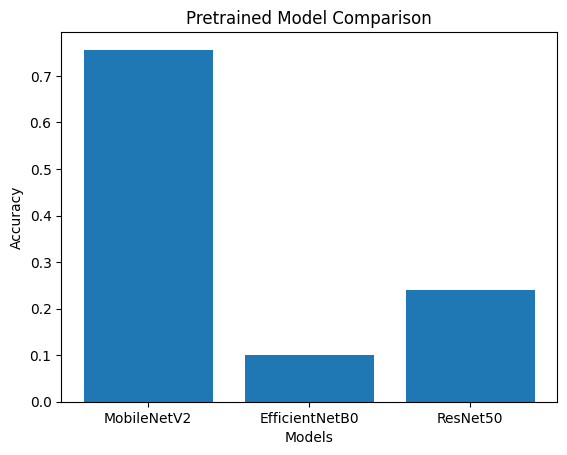

In [9]:
models = ["MobileNetV2", "EfficientNetB0", "ResNet50"]
accuracies = [mobilenet_acc, efficientnet_acc, resnet_acc]

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Pretrained Model Comparison")

plt.show()

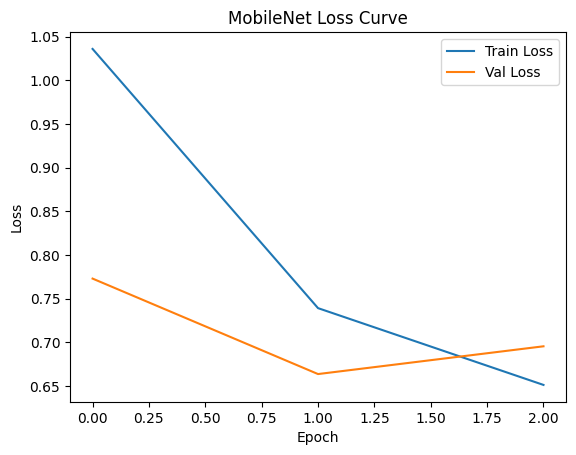

In [10]:
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Val Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNet Loss Curve")

plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step


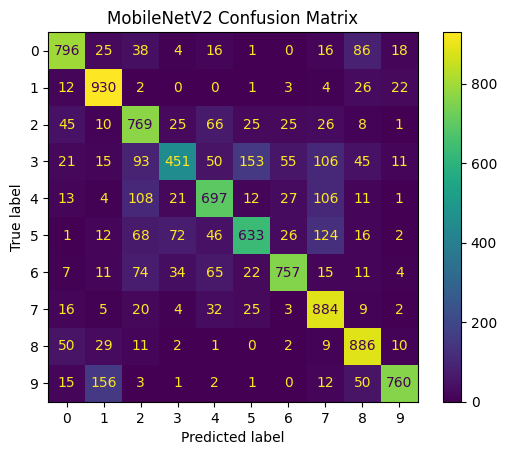

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step


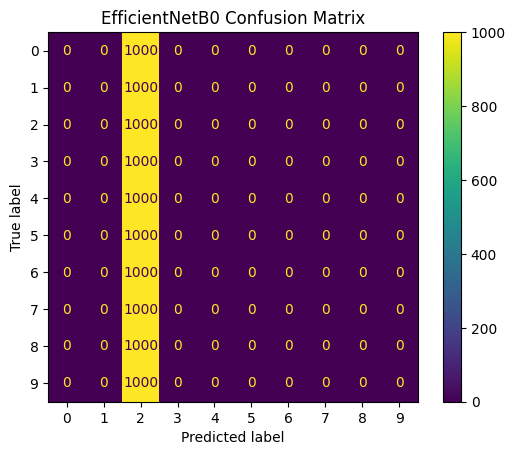

313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 165ms/step


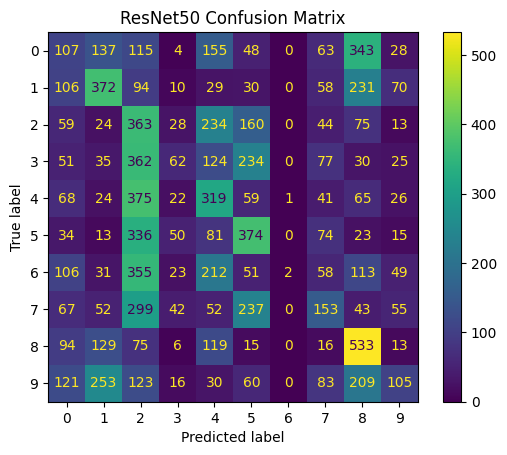

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(model, X_test, y_test, title):

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(title)
    plt.show()


# Plot for all 3 models
plot_confusion(mobilenet_model, X_test, y_test, "MobileNetV2 Confusion Matrix")
plot_confusion(efficientnet_model, X_test, y_test, "EfficientNetB0 Confusion Matrix")
plot_confusion(resnet_model, X_test, y_test, "ResNet50 Confusion Matrix")

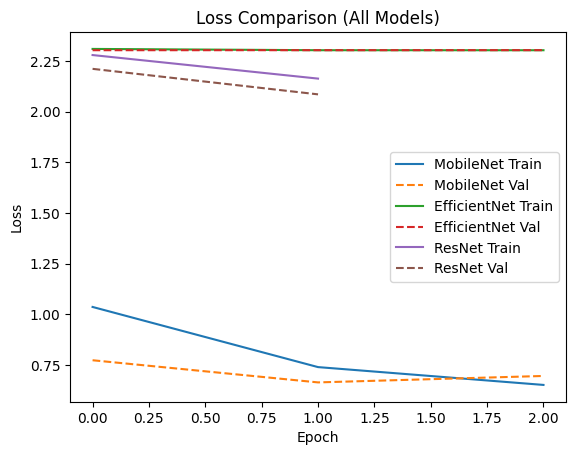

In [12]:
plt.figure()

# MobileNet
plt.plot(history_mobilenet.history['loss'], label='MobileNet Train')
plt.plot(history_mobilenet.history['val_loss'], linestyle='--', label='MobileNet Val')

# EfficientNet
plt.plot(history_efficientnet.history['loss'], label='EfficientNet Train')
plt.plot(history_efficientnet.history['val_loss'], linestyle='--', label='EfficientNet Val')

# ResNet
plt.plot(history_resnet.history['loss'], label='ResNet Train')
plt.plot(history_resnet.history['val_loss'], linestyle='--', label='ResNet Val')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison (All Models)")

plt.legend()
plt.show()

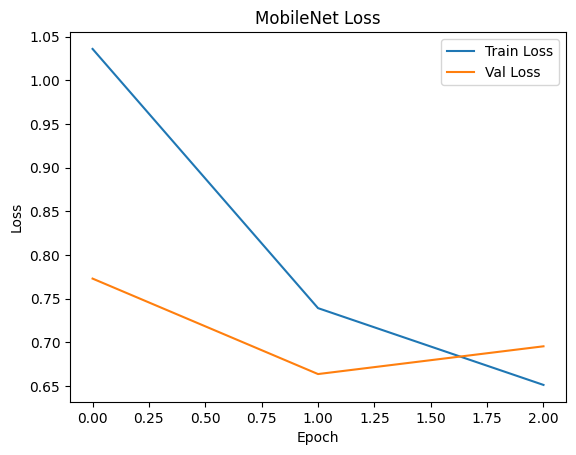

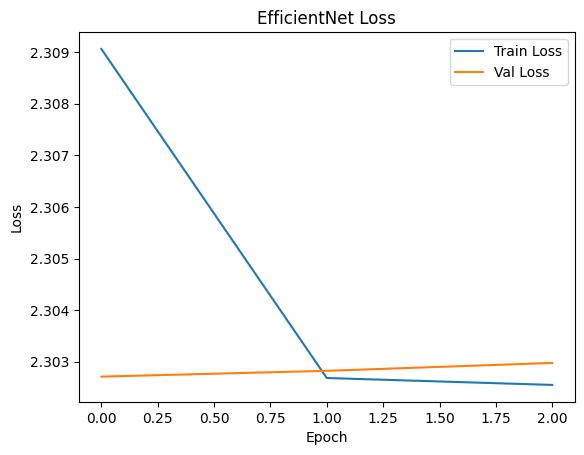

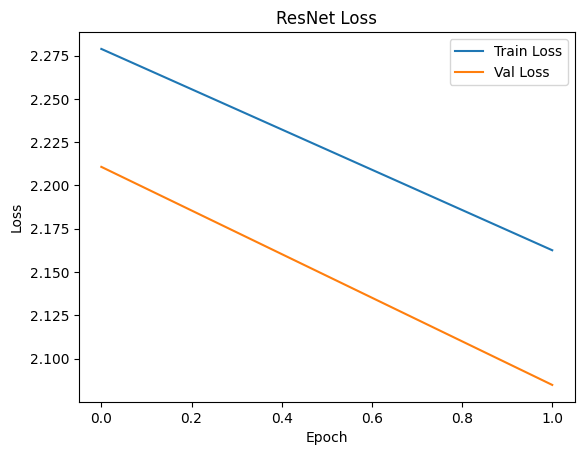

In [13]:
def plot_loss(history, title):
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

plot_loss(history_mobilenet, "MobileNet Loss")
plot_loss(history_efficientnet, "EfficientNet Loss")
plot_loss(history_resnet, "ResNet Loss")